In [4]:
import pandas as pd

In [5]:
asr=pd.read_csv('AirlineScrappedReview_Cleaned.csv')

In [6]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3575 entries, 0 to 3574
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Passanger_Name   3500 non-null   object 
 1   Flying_Date      955 non-null    object 
 2   Route            2807 non-null   object 
 3   Rating           3501 non-null   float64
 4   Verified         3501 non-null   object 
 5   Review_title     3501 non-null   object 
 6   Review_content   3501 non-null   object 
 7   Traveller_Type   3501 non-null   object 
 8   Class            3501 non-null   object 
 9   Start_Location   2807 non-null   object 
 10  End_Location     2807 non-null   object 
 11  Layover_Route    484 non-null    object 
 12  Start_Latitude   3441 non-null   float64
 13  Start_Longitude  3441 non-null   float64
 14  Start_Address    3441 non-null   object 
 15  End_Latitude     3402 non-null   float64
 16  End_Longitude    3402 non-null   float64
 17  End_Address   

Dropped Flying_Date column

In [7]:
asr=asr.drop(columns=['Flying_Date'],axis=1)

In [8]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3575 entries, 0 to 3574
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Passanger_Name   3500 non-null   object 
 1   Route            2807 non-null   object 
 2   Rating           3501 non-null   float64
 3   Verified         3501 non-null   object 
 4   Review_title     3501 non-null   object 
 5   Review_content   3501 non-null   object 
 6   Traveller_Type   3501 non-null   object 
 7   Class            3501 non-null   object 
 8   Start_Location   2807 non-null   object 
 9   End_Location     2807 non-null   object 
 10  Layover_Route    484 non-null    object 
 11  Start_Latitude   3441 non-null   float64
 12  Start_Longitude  3441 non-null   float64
 13  Start_Address    3441 non-null   object 
 14  End_Latitude     3402 non-null   float64
 15  End_Longitude    3402 non-null   float64
 16  End_Address      3402 non-null   object 
dtypes: float64(5),

In [9]:
asr['Layover_Route'].value_counts()

Layover_Route
London                                           197
London - Heathrow                                151
Heathrow                                          31
London Heathrow                                   21
Singapore                                         17
Singapore - Changi                                 9
Gatwick                                            6
London                                             5
Bahrain - Bahrain International Airport            3
London Heathrow                                    2
Johannesburg - OR Tambo International Airport      2
London - Gatwick                                   2
Dublin                                             1
Chicago / London                                   1
Toronto / London                                   1
London,                                            1
Los Angeles                                        1
Doha                                               1
Copenhagen                      

In [10]:
asr.shape

(3575, 17)

In [11]:
asr.isnull().all(axis=1).any()

np.True_

In [12]:
empty_rows = asr[asr.isnull().all(axis=1)]

In [13]:
len(empty_rows)

74

Dropped all empty rows

In [14]:
asr = asr.dropna(how='all')

In [15]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3501 entries, 0 to 3500
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Passanger_Name   3500 non-null   object 
 1   Route            2807 non-null   object 
 2   Rating           3501 non-null   float64
 3   Verified         3501 non-null   object 
 4   Review_title     3501 non-null   object 
 5   Review_content   3501 non-null   object 
 6   Traveller_Type   3501 non-null   object 
 7   Class            3501 non-null   object 
 8   Start_Location   2807 non-null   object 
 9   End_Location     2807 non-null   object 
 10  Layover_Route    484 non-null    object 
 11  Start_Latitude   3441 non-null   float64
 12  Start_Longitude  3441 non-null   float64
 13  Start_Address    3441 non-null   object 
 14  End_Latitude     3402 non-null   float64
 15  End_Longitude    3402 non-null   float64
 16  End_Address      3402 non-null   object 
dtypes: float64(5), obje

In [16]:
asr_unknown_passanger_name=asr[asr['Passanger_Name'].isnull()]
len(asr_unknown_passanger_name)

1

In [17]:
asr_unknown_passanger_name.head()

,Passanger_Name,Route,Rating,Verified,Review_title,Review_content,Traveller_Type,Class,Start_Location,End_Location,Layover_Route,Start_Latitude,Start_Longitude,Start_Address,End_Latitude,End_Longitude,End_Address
3113,NaN,NaN,7.0,Not Verified,British Airways customer review,HKG-LHR-Bergen: Stockholm-LHR-HKG - A380 on lo...,Business,Business Class,NaN,NaN,NaN,46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ...",46.314475,11.048029,"Nanno, Ville d'Anaunia, Comunità della Val di ..."


In [18]:
asr_with_same_start_and_end_address=asr[(asr['Start_Address']==asr['End_Address'])]
len(asr_with_same_start_and_end_address)

694

Dropped the rows that have same start and end_address

In [19]:
asr.drop(asr_with_same_start_and_end_address.index, inplace=True)

In [20]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2807 entries, 0 to 2812
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Passanger_Name   2807 non-null   object 
 1   Route            2807 non-null   object 
 2   Rating           2807 non-null   float64
 3   Verified         2807 non-null   object 
 4   Review_title     2807 non-null   object 
 5   Review_content   2807 non-null   object 
 6   Traveller_Type   2807 non-null   object 
 7   Class            2807 non-null   object 
 8   Start_Location   2807 non-null   object 
 9   End_Location     2807 non-null   object 
 10  Layover_Route    484 non-null    object 
 11  Start_Latitude   2747 non-null   float64
 12  Start_Longitude  2747 non-null   float64
 13  Start_Address    2747 non-null   object 
 14  End_Latitude     2708 non-null   float64
 15  End_Longitude    2708 non-null   float64
 16  End_Address      2708 non-null   object 
dtypes: float64(5), obje

In [21]:
asr_with_null_start_address_and_end_address=asr[(asr['Start_Address'].isnull()) & (asr['End_Address'].isnull())]
len(asr_with_null_start_address_and_end_address)

0

In [22]:
asr_with_null_start_address=asr[(asr['Start_Address'].isnull())]
len(asr_with_null_start_address)


60

In [23]:
asr_with_null_start_address.head()

,Passanger_Name,Route,Rating,Verified,Review_title,Review_content,Traveller_Type,Class,Start_Location,End_Location,Layover_Route,Start_Latitude,Start_Longitude,Start_Address,End_Latitude,End_Longitude,End_Address
1019,Roger Stone,HKG to LHR,8.0,Trip Verified,an enjoyable experience,I thought it time BA deserved some compliments...,Business,Premium Economy,Hong Kong - International Airport (HKIA),London Heathrow,NaN,NaN,NaN,NaN,51.467739,-0.458780,"London Heathrow Airport, Northern Perimeter Ro..."
1168,Carlos Arenas,Edimbourgh to London Gatwick,3.0,Trip Verified,I end up with mix feelings,I have traveled several times with British Air...,Couple Leisure,Economy Class,Edimbourgh,London Gatwick,NaN,NaN,NaN,NaN,51.154108,-0.182312,"London Gatwick Airport, Perimeter Road East, L..."
1360,John Barry,Zakinthos to London Heathrow,8.0,Not Verified,very good flight again,Verified Review Zakinthos to London Heathrow...,Family Leisure,Business Class,Zakinthos,London Heathrow,NaN,NaN,NaN,NaN,51.467739,-0.458780,"London Heathrow Airport, Northern Perimeter Ro..."
1737,Vincent Borlaug,IAD to BCN via LHR,10.0,Not Verified,still my first choice,Verified Review Washington to Barcelona retu...,Solo Leisure,Premium Economy,Washington DC - Dulles International,Barcelona,London - Heathrow,NaN,NaN,NaN,41.382894,2.177432,"Barcelona, Barcelonès, Barcelona, Catalunya, 0..."
1749,J Hicklin,SFO to JNB via LHR,6.0,Not Verified,as different as night and day,Verified Review San Francisco to Johannesbur...,Solo Leisure,Business Class,"San Francisco - International Airport, SA",Johannesburg - OR Tambo International Airport,London - Heathrow,NaN,NaN,NaN,-26.136013,28.244977,"O.R. Tambo International Airport, Elgin Street..."


In [24]:
asr_start_location_london=asr[(asr['Start_Location']=='London')]
len(asr_start_location_london)

498

In [25]:
asr_start_location_london.head()

,Passanger_Name,Route,Rating,Verified,Review_title,Review_content,Traveller_Type,Class,Start_Location,End_Location,Layover_Route,Start_Latitude,Start_Longitude,Start_Address,End_Latitude,End_Longitude,End_Address
1,S Layne,London to Amman,1.0,Trip Verified,fully refunded by our travel insurance,"We booked on the BA website, round trip flight...",Couple Leisure,Business Class,London,Amman,NaN,51.507446,-0.127765,"London, Greater London, England, United Kingdom",31.951569,35.923963,"عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110,..."
5,M King,London to Washington,1.0,Trip Verified,Communication is terrible,Absolutely horrible airline. Communication is ...,Couple Leisure,Economy Class,London,Washington,NaN,51.507446,-0.127765,"London, Greater London, England, United Kingdom",38.895037,-77.036543,"Washington, District of Columbia, United States"
8,Carol Willmore,London to Funchal,1.0,Not Verified,flight failed at every level,This flight failed at every level. We were del...,Couple Leisure,Economy Class,London,Funchal,NaN,51.507446,-0.127765,"London, Greater London, England, United Kingdom",32.649650,-16.908678,"Funchal, Madeira, Portugal"
24,K Parker,London to Santorini,1.0,Trip Verified,The worst experience,The worst experience in all my years of travel...,Couple Leisure,Economy Class,London,Santorini,NaN,51.507446,-0.127765,"London, Greater London, England, United Kingdom",36.407111,25.456664,"Σαντορίνη, Δημοτική Ενότητα Θήρας, Δήμος Θήρας..."
26,Christos Hadjipanayi,London to Larnaca,10.0,Trip Verified,the crew has helped me,A serious medical problem appeared while I was...,Solo Leisure,Economy Class,London,Larnaca,NaN,51.507446,-0.127765,"London, Greater London, England, United Kingdom",34.923609,33.623618,"Δήμος Λάρνακας, Λάρνακα, Κύπρος, Κύπρος - Kıbrıs"


In [26]:
asr_with_null_start_address_and_start_latitude_not_null=asr[(asr['Start_Address'].isnull()) & (asr['Start_Latitude'].notnull())]
len(asr_with_null_start_address_and_start_latitude_not_null)

0

In [27]:
asr_with_null_start_address_and_start_longitude_not_null=asr[(asr['Start_Address'].isnull()) & (asr['Start_Longitude'].notnull())]
len(asr_with_null_start_address_and_start_longitude_not_null)

0

In [28]:
import re

def extract_locations_from_route(route_text):
    """Extract origin and destination as CITY NAMES (not codes), ignoring layovers"""
    if pd.isna(route_text) or str(route_text).strip() == '':
        return None, None
    
    route = str(route_text).strip()
    
    # Handle 'via' routes - get origin and destination before 'via'
    if ' via ' in route.lower():
        parts = route.lower().split(' via ')
        main_route = parts[0].strip()
        
        # Try airport codes in main route
        match = re.search(r'([A-Z]{3})\s+to\s+([A-Z]{3})', main_route, re.IGNORECASE)
        if match:
            return code_to_city(match.group(1)), code_to_city(match.group(2))
        
        # Try city names
        match = re.search(r'(.+?)\s+to\s+(.+)', main_route, re.IGNORECASE)
        if match:
            return normalize_city(match.group(1)), normalize_city(match.group(2))
    
    # Direct routes with airport codes
    match = re.search(r'([A-Z]{3})\s+to\s+([A-Z]{3})', route, re.IGNORECASE)
    if match:
        return code_to_city(match.group(1)), code_to_city(match.group(2))
    
    # Direct routes with city names
    match = re.search(r'(.+?)\s+to\s+(.+)', route, re.IGNORECASE)
    if match:
        return normalize_city(match.group(1)), normalize_city(match.group(2))
    
    # Hyphen format
    match = re.search(r'([A-Z]{3})\s*[-–]\s*([A-Z]{3})', route)
    if match:
        return code_to_city(match.group(1)), code_to_city(match.group(2))
    
    return None, None

def code_to_city(code):
    """Convert 3-letter airport code to city name"""
    code = code.upper().strip()
    
    code_map = {
        'LHR': 'London', 'LGW': 'London', 'LCY': 'London',
        'JFK': 'New York', 'EWR': 'Newark', 'LGA': 'New York',
        'LAX': 'Los Angeles', 'SFO': 'San Francisco', 'SAN': 'San Diego',
        'ORD': 'Chicago', 'MIA': 'Miami', 'BOS': 'Boston',
        'IAD': 'Washington', 'DXB': 'Dubai', 'SIN': 'Singapore',
        'HKG': 'Hong Kong', 'BKK': 'Bangkok', 'JNB': 'Johannesburg',
        'CPT': 'Cape Town', 'SYD': 'Sydney', 'YYZ': 'Toronto',
        'YVR': 'Vancouver', 'BOM': 'Mumbai', 'DEL': 'Delhi',
        'AMS': 'Amsterdam', 'CDG': 'Paris', 'ORY': 'Paris',
        'FRA': 'Frankfurt', 'MAD': 'Madrid', 'BCN': 'Barcelona',
        'FCO': 'Rome', 'IST': 'Istanbul', 'DOH': 'Doha',
        'ATH': 'Athens', 'LIS': 'Lisbon', 'GVA': 'Geneva',
        'BRU': 'Brussels', 'DUB': 'Dublin', 'EDI': 'Edinburgh',
        'GLA': 'Glasgow', 'MAN': 'Manchester', 'AGP': 'Malaga',
        'LCA': 'Larnaca', 'TLV': 'Tel Aviv', 'BGI': 'Barbados',
        'MCO': 'Orlando', 'LAS': 'Las Vegas', 'SEA': 'Seattle',
        'PHX': 'Phoenix', 'CPH': 'Copenhagen', 'ARN': 'Stockholm',
        'VIE': 'Vienna', 'ZRH': 'Zurich', 'PRG': 'Prague',
        'TXL': 'Berlin', 'MUC': 'Munich', 'MXP': 'Milan',
        'DEN': 'Denver', 'ATL': 'Atlanta', 'DFW': 'Dallas',
        'PHL': 'Philadelphia', 'TPA': 'Tampa', 'AUS': 'Austin',
        'BWI': 'Baltimore', 'IAH': 'Houston', 'YUL': 'Montreal',
        'YYC': 'Calgary', 'BHD': 'Belfast', 'ABZ': 'Aberdeen',
        'NCL': 'Newcastle', 'NRT': 'Tokyo', 'HND': 'Tokyo',
        'ICN': 'Seoul', 'PEK': 'Beijing', 'PVG': 'Shanghai',
        'BLR': 'Bangalore', 'MAA': 'Chennai', 'HYD': 'Hyderabad',
        'KUL': 'Kuala Lumpur', 'AUH': 'Abu Dhabi', 'NBO': 'Nairobi',
        'ACC': 'Accra', 'CAI': 'Cairo', 'MRU': 'Mauritius',
        'MLE': 'Male', 'UVF': 'St Lucia', 'ANU': 'Antigua',
        'CUN': 'Cancun', 'PSA': 'Pisa', 'VCE': 'Venice',
        'FLR': 'Florence', 'BLQ': 'Bologna', 'NAP': 'Naples',
        'NCE': 'Nice', 'LYS': 'Lyon', 'MRS': 'Marseille',
        'TLS': 'Toulouse', 'GRU': 'Sao Paulo', 'GIG': 'Rio de Janeiro',
        'EZE': 'Buenos Aires', 'LIM': 'Lima', 'SCL': 'Santiago',
        'MEX': 'Mexico City', 'KEF': 'Reykjavik', 'RAK': 'Marrakech',
        'FAO': 'Faro', 'FNC': 'Funchal', 'TFS': 'Tenerife',
        'JTR': 'Santorini', 'JMK': 'Mykonos', 'DBV': 'Dubrovnik',
        'WAW': 'Warsaw', 'BUD': 'Budapest', 'OTP': 'Bucharest',
        'SOF': 'Sofia', 'KRK': 'Krakow', 'HAM': 'Hamburg',
        'DUS': 'Dusseldorf', 'STR': 'Stuttgart', 'CGN': 'Cologne',
    }
    
    return code_map.get(code, code)

def normalize_city(city_name):
    """Normalize city name variations to standard names"""
    city = city_name.strip()
    
    city_map = {
        'London': 'London', 'London Heathrow': 'London', 'Heathrow': 'London',
        'London Gatwick': 'London', 'Gatwick': 'London', 
        'London City': 'London', 'London Heaathrow': 'London',
        'New York': 'New York', 'New York JFK': 'New York',
        'Los Angeles': 'Los Angeles', 'Los Angesles': 'Los Angeles',
        'San Francisco': 'San Francisco',
        'Chicago': 'Chicago', "Chicago O'Hare": 'Chicago',
        'Miami': 'Miami', 'Boston': 'Boston',
        'Washington': 'Washington', 'Washington Dulles': 'Washington', 'Washington DC': 'Washington',
        'Dubai': 'Dubai', 'Singapore': 'Singapore', 'Singapire': 'Singapore',
        'Hong Kong': 'Hong Kong', 'Bangkok': 'Bangkok',
        'Johannesburg': 'Johannesburg', 'Cape Town': 'Cape Town',
        'Sydney': 'Sydney', 'Toronto': 'Toronto', 'Vancouver': 'Vancouver',
        'Mumbai': 'Mumbai', 'Bombay': 'Mumbai',
        'Delhi': 'Delhi', 'New Delhi': 'Delhi',
        'Amsterdam': 'Amsterdam', 'Paris': 'Paris', 'Paris CDG': 'Paris', 'Paris Orly': 'Paris',
        'Frankfurt': 'Frankfurt', 'Madrid': 'Madrid', 'Barcelona': 'Barcelona',
        'Rome': 'Rome', 'Rome Fiumicino': 'Rome',
        'Istanbul': 'Istanbul', 'Istambul': 'Istanbul',
        'Doha': 'Doha', 'Athens': 'Athens', 'Athens Greece': 'Athens',
        'Lisbon': 'Lisbon', 'Geneva': 'Geneva', 'Brussels': 'Brussels',
        'Dublin': 'Dublin', 'Edinburgh': 'Edinburgh', 'Edimbourgh': 'Edinburgh',
        'Glasgow': 'Glasgow', 'Manchester': 'Manchester',
        'Malaga': 'Malaga', 'Larnaca': 'Larnaca', 'Larnaca Cyprus': 'Larnaca',
        'Tel Aviv': 'Tel Aviv', 'Barbados': 'Barbados', 'Bridgetown': 'Barbados',
        'Orlando': 'Orlando', 'Las Vegas': 'Las Vegas',
        'Seattle': 'Seattle', 'Seattle Tacoma': 'Seattle',
        'Phoenix': 'Phoenix', 'Copenhagen': 'Copenhagen',
        'Stockholm': 'Stockholm', 'Stockholm Arlanda': 'Stockholm',
        'Vienna': 'Vienna', 'Zurich': 'Zurich', 'Zürich': 'Zurich',
        'Prague': 'Prague', 'Berlin': 'Berlin', 'Berlin Tegel': 'Berlin',
        'Munich': 'Munich', 'Milan': 'Milan', 'Milan Malpensa': 'Milan',
        'Denver': 'Denver', 'Atlanta': 'Atlanta',
        'Dallas': 'Dallas', 'Dallas Fort-Worth': 'Dallas',
        'Philadelphia': 'Philadelphia', 'Tampa': 'Tampa',
        'Austin': 'Austin', 'Newark': 'Newark',
        'Baltimore': 'Baltimore', 'Houston': 'Houston',
        'San Diego': 'San Diego', 'Montreal': 'Montreal', 'Montréal': 'Montreal',
        'Calgary': 'Calgary', 'Belfast': 'Belfast', 'Belfast City': 'Belfast',
        'Aberdeen': 'Aberdeen', 'Newcastle': 'Newcastle',
        'Tokyo': 'Tokyo', 'Tokyo Narita': 'Tokyo', 'Tokyo Haneda': 'Tokyo',
        'Seoul': 'Seoul', 'Seoul Incheon': 'Seoul',
        'Beijing': 'Beijing', 'Shanghai': 'Shanghai',
        'Bangalore': 'Bangalore', 'Bengaluru': 'Bangalore',
        'Chennai': 'Chennai', 'Hyderabad': 'Hyderabad',
        'Kuala Lumpur': 'Kuala Lumpur', 'Abu Dhabi': 'Abu Dhabi',
        'Nairobi': 'Nairobi', 'Accra': 'Accra', 'Cairo': 'Cairo',
    }
    
    return city_map.get(city, city)

# Find rows with missing Start_Address or End_Address
print("Processing rows with missing Start_Address or End_Address...")
missing = asr['Start_Address'].isna() | asr['End_Address'].isna()
print(f"Rows with missing address data: {missing.sum()}")

# Extract city names from Route
results = asr[missing]['Route'].apply(extract_locations_from_route)
extracted_df = pd.DataFrame(results.tolist(), columns=['Start', 'End'], index=asr[missing].index)

# Update dataframe with city names
start_count = 0
end_count = 0

for idx in extracted_df.index:
    if pd.isna(asr.loc[idx, 'Start_Address']) and pd.notna(extracted_df.loc[idx, 'Start']):
        asr.loc[idx, 'Start_Address'] = extracted_df.loc[idx, 'Start']
        start_count += 1
    
    if pd.isna(asr.loc[idx, 'End_Address']) and pd.notna(extracted_df.loc[idx, 'End']):
        asr.loc[idx, 'End_Address'] = extracted_df.loc[idx, 'End']
        end_count += 1

print(f"\nUpdated {start_count} Start_Address values with city names")
print(f"Updated {end_count} End_Address values with city names")
print(f"\nRemaining missing Start_Address: {asr['Start_Address'].isna().sum()}")
print(f"Remaining missing End_Address: {asr['End_Address'].isna().sum()}")

# Show some examples
print("\nSample extractions:")
sample = extracted_df[extracted_df['Start'].notna()].head(5)
for idx, row in sample.iterrows():
    route = asr.loc[idx, 'Route']
    print(f"Route: '{route}'")
    print(f"  -> Start: {row['Start']}, End: {row['End']}")
    print()

Processing rows with missing Start_Address or End_Address...
Rows with missing address data: 159

Updated 60 Start_Address values with city names
Updated 99 End_Address values with city names

Remaining missing Start_Address: 0
Remaining missing End_Address: 0

Sample extractions:
Route: 'Dubai to London Heaathrow'
  -> Start: BAI, End: LON

Route: 'doha to londonDoha to London'
  -> Start: OHA, End: LON

Route: 'HKG to LHR'
  -> Start: Hong Kong, End: London

Route: 'Frankfurt to London Cuty'
  -> Start: URT, End: LON

Route: 'Edimbourgh to London Gatwick'
  -> Start: RGH, End: LON



In [29]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2807 entries, 0 to 2812
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Passanger_Name   2807 non-null   object 
 1   Route            2807 non-null   object 
 2   Rating           2807 non-null   float64
 3   Verified         2807 non-null   object 
 4   Review_title     2807 non-null   object 
 5   Review_content   2807 non-null   object 
 6   Traveller_Type   2807 non-null   object 
 7   Class            2807 non-null   object 
 8   Start_Location   2807 non-null   object 
 9   End_Location     2807 non-null   object 
 10  Layover_Route    484 non-null    object 
 11  Start_Latitude   2747 non-null   float64
 12  Start_Longitude  2747 non-null   float64
 13  Start_Address    2807 non-null   object 
 14  End_Latitude     2708 non-null   float64
 15  End_Longitude    2708 non-null   float64
 16  End_Address      2807 non-null   object 
dtypes: float64(5), obje

In [30]:
asr['Layover_Route'].value_counts()

Layover_Route
London                                           197
London - Heathrow                                151
Heathrow                                          31
London Heathrow                                   21
Singapore                                         17
Singapore - Changi                                 9
Gatwick                                            6
London                                             5
Bahrain - Bahrain International Airport            3
London Heathrow                                    2
Johannesburg - OR Tambo International Airport      2
London - Gatwick                                   2
Dublin                                             1
Chicago / London                                   1
Toronto / London                                   1
London,                                            1
Los Angeles                                        1
Doha                                               1
Copenhagen                      

Filled all the null values in the Layover_Route with None as they are direct flights not transit (we checked through the route column for the via to make sure)

In [31]:
asr['Layover_Route'].fillna('None', inplace=True)

C:\Users\Legion\AppData\Local\Temp\ipykernel_35128\63432947.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  asr['Layover_Route'].fillna('None', inplace=True)


In [32]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2807 entries, 0 to 2812
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Passanger_Name   2807 non-null   object 
 1   Route            2807 non-null   object 
 2   Rating           2807 non-null   float64
 3   Verified         2807 non-null   object 
 4   Review_title     2807 non-null   object 
 5   Review_content   2807 non-null   object 
 6   Traveller_Type   2807 non-null   object 
 7   Class            2807 non-null   object 
 8   Start_Location   2807 non-null   object 
 9   End_Location     2807 non-null   object 
 10  Layover_Route    2807 non-null   object 
 11  Start_Latitude   2747 non-null   float64
 12  Start_Longitude  2747 non-null   float64
 13  Start_Address    2807 non-null   object 
 14  End_Latitude     2708 non-null   float64
 15  End_Longitude    2708 non-null   float64
 16  End_Address      2807 non-null   object 
dtypes: float64(5), obje

In [33]:
asr.to_csv('AirlineScrappedReview_Cleaned_seif_we_ibra#1.csv', index=False)

In [34]:
asr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2807 entries, 0 to 2812
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Passanger_Name   2807 non-null   object 
 1   Route            2807 non-null   object 
 2   Rating           2807 non-null   float64
 3   Verified         2807 non-null   object 
 4   Review_title     2807 non-null   object 
 5   Review_content   2807 non-null   object 
 6   Traveller_Type   2807 non-null   object 
 7   Class            2807 non-null   object 
 8   Start_Location   2807 non-null   object 
 9   End_Location     2807 non-null   object 
 10  Layover_Route    2807 non-null   object 
 11  Start_Latitude   2747 non-null   float64
 12  Start_Longitude  2747 non-null   float64
 13  Start_Address    2807 non-null   object 
 14  End_Latitude     2708 non-null   float64
 15  End_Longitude    2708 non-null   float64
 16  End_Address      2807 non-null   object 
dtypes: float64(5), obje

In [35]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Legion\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [36]:
sia = SentimentIntensityAnalyzer()


In [64]:
asr_new1=asr.copy()
asr_new1['Full_review'] = asr['Review_title'].fillna('') + " : " + asr['Review_content'].fillna('')


In [68]:
asr_new2=asr.copy()

In [65]:
asr_new1['sentiment'] = asr_new1['Full_review'].astype(str).apply(lambda x: sia.polarity_scores(x)['compound'])


In [66]:
def get_sentiment_label(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'


asr_new1['sentiment_label'] = asr_new1['sentiment'].apply(get_sentiment_label)

In [67]:
asr_new1['sentiment_label'].value_counts()

sentiment_label
Positive    1559
Negative    1243
Neutral        5
Name: count, dtype: int64

In [60]:
import numpy as np

bins = np.arange(-1, 1.1, 0.1)  # from -1 to 1 in steps of 0.1
asr_new1['sentiment_bin'] = pd.cut(asr_new1['sentiment'], bins=bins, include_lowest=True)
asr_new1['sentiment_bin'].value_counts().sort_index()

sentiment_bin
(-1.001, -0.9]       453
(-0.9, -0.8]         247
(-0.8, -0.7]         134
(-0.7, -0.6]          98
(-0.6, -0.5]          80
(-0.5, -0.4]          57
(-0.4, -0.3]          63
(-0.3, -0.2]          47
(-0.2, -0.1]          36
(-0.1, -2.22e-16]     28
(-2.22e-16, 0.1]      34
(0.1, 0.2]            45
(0.2, 0.3]            51
(0.3, 0.4]            51
(0.4, 0.5]            69
(0.5, 0.6]            64
(0.6, 0.7]            83
(0.7, 0.8]           121
(0.8, 0.9]           224
(0.9, 1.0]           822
Name: count, dtype: int64

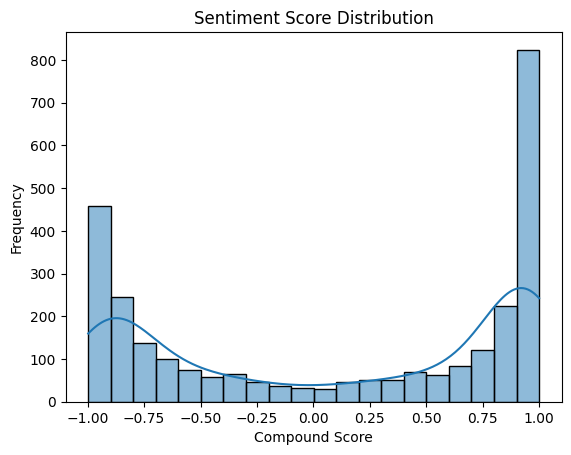

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(asr_new1['sentiment'], bins=20, kde=True)
plt.title('Sentiment Score Distribution')
plt.xlabel('Compound Score')
plt.ylabel('Frequency')
plt.show()


In [62]:
asr_new1_with_neutral_sentiments=asr_new1[asr_new1['sentiment_label']=='Neutral']
len(asr_new1_with_neutral_sentiments)

5

In [63]:
pd.set_option('display.max_colwidth', None)
asr_new1_with_neutral_sentiments.head(5)

,Passanger_Name,Route,Rating,Verified,Review_title,Review_content,Traveller_Type,Class,Start_Location,End_Location,...,Start_Latitude,Start_Longitude,Start_Address,End_Latitude,End_Longitude,End_Address,Full_review,sentiment,sentiment_label,sentiment_bin
162,M Beale,Miami to Budapest via London,1.0,Trip Verified,wouldn't let me check-in until 24 hours before,"British Airways is late, their website is atrocious, and they wouldn't let me check-in until 24 hours before the flight. I have been trying for 6 hours to check in through their website, and/or find a real person to speak with. Customer service had such a thick accent I didn't think they were speaking English.",Solo Leisure,Economy Class,Miami,Budapest,...,25.774173,-80.193620,"Miami, Miami-Dade County, Florida, United States",47.497892,19.040161,"Budapest, Közép-Magyarország, Magyarország","wouldn't let me check-in until 24 hours before British Airways is late, their website is atrocious, and they wouldn't let me check-in until 24 hours before the flight. I have been trying for 6 hours to check in through their website, and/or find a real person to speak with. Customer service had such a thick accent I didn't think they were speaking English.",0.0,Neutral,"(-2.22e-16, 0.1]"
370,M Karvin,Frankfurt to London,1.0,Trip Verified,my booked seat is not available,"After 1h queuing at the check-in desk, I am told that my booked seat is not available. Why do you sell seats that you do not have?",Business,Economy Class,Frankfurt,London,...,50.110644,8.682092,"Frankfurt am Main, Hessen, Deutschland",51.507446,-0.127765,"London, Greater London, England, United Kingdom","my booked seat is not available After 1h queuing at the check-in desk, I am told that my booked seat is not available. Why do you sell seats that you do not have?",0.0,Neutral,"(-2.22e-16, 0.1]"
495,Joe Merieux,London to Seattle,3.0,Trip Verified,British Airways customer review,"I am flying London to Seattle in Business Class in May 2020, and British Airways wants around £100 each way for me to choose seats. All other airlines I have encountered allow Business Class passengers to choose seats at no additional cost. They decided to change my seat ""for operational reasons""s. What could that reason be? The plane is the same. So, BA takes £100 off me for me so that I can choose my seat and then changes my seat - without asking me. What I get is an automated message (the next time I log on to the BA website) to tell me. There is a number I can ring, 40 minutes waiting for the phone to be answered and I give up.",Business,Business Class,London,Seattle,...,51.507446,-0.127765,"London, Greater London, England, United Kingdom",47.603832,-122.330062,"Seattle, King County, Washington, United States","British Airways customer review I am flying London to Seattle in Business Class in May 2020, and British Airways wants around £100 each way for me to choose seats. All other airlines I have encountered allow Business Class passengers to choose seats at no additional cost. They decided to change my seat ""for operational reasons""s. What could that reason be? The plane is the same. So, BA takes £100 off me for me so that I can choose my seat and then changes my seat - without asking me. What I get is an automated message (the next time I log on to the BA website) to tell me. There is a number I can ring, 40 minutes waiting for the phone to be answered and I give up.",0.0,Neutral,"(-2.22e-16, 0.1]"
1119,L Harper,Gatwick to Barbados,4.0,Trip Verified,cheaper than competitors,"Gatwick to Barbados in December 2017. On a 9 hour flight they provided one meal, and afternoon tea which consisted of a mars bar and a cup of tea. The plane was aging and yellowing round the edges and the staff were surly. The only redeeming thing was that it was cheaper than competitors (but still not cheap).",Couple Leisure,Economy Class,London Gatwick,Barbados,...,51.154108,-0.182312,"London Gatwick Airport, Perimeter Road East, Lowfield Heath, Crawley, West 

In [74]:
asr_new1_with_close_positive_sentiments=asr_new1[asr_new1['sentiment'].between(0.1, 0.2)]
len(asr_new1_with_close_positive_sentiments)

45

In [76]:
asr_new2=asr.copy()
asr_new2['sentiment'] = asr_new2['Review_content'].astype(str).apply(lambda x: sia.polarity_scores(x)['compound'])
asr_new2['sentiment_label'] = asr_new2['sentiment'].apply(lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral'))

In [78]:
asr_new3=asr.copy()
asr_new3['sentiment'] = asr_new3['Review_title'].astype(str).apply(lambda x: sia.polarity_scores(x)['compound'])
asr_new3['sentiment_label'] = asr_new3['sentiment'].apply(lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral'))

In [88]:
asr_new1['sentiment_label'].value_counts()

sentiment_label
Positive    1559
Negative    1243
Neutral        5
Name: count, dtype: int64

In [87]:
asr_new2['sentiment_label'].value_counts()

sentiment_label
positive    1558
negative    1209
neutral       40
Name: count, dtype: int64

In [79]:
asr_new3['sentiment_label'].value_counts()

sentiment_label
neutral     1113
negative     881
positive     813
Name: count, dtype: int64

In [72]:
asr_new1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2807 entries, 0 to 2812
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Passanger_Name   2807 non-null   object 
 1   Route            2807 non-null   object 
 2   Rating           2807 non-null   float64
 3   Verified         2807 non-null   object 
 4   Review_title     2807 non-null   object 
 5   Review_content   2807 non-null   object 
 6   Traveller_Type   2807 non-null   object 
 7   Class            2807 non-null   object 
 8   Start_Location   2807 non-null   object 
 9   End_Location     2807 non-null   object 
 10  Layover_Route    2807 non-null   object 
 11  Start_Latitude   2747 non-null   float64
 12  Start_Longitude  2747 non-null   float64
 13  Start_Address    2807 non-null   object 
 14  End_Latitude     2708 non-null   float64
 15  End_Longitude    2708 non-null   float64
 16  End_Address      2807 non-null   object 
 17  Full_review      28

In [93]:
import nltk
nltk.download('punkt')

def vader_on_sentences(text):
    sentences = nltk.sent_tokenize(text)
    if not sentences:
        return 0
    scores = [sia.polarity_scores(sentence)['compound'] for sentence in sentences]
    return sum(scores) / len(scores)

asr_new4 = asr.copy()
asr_new4['Full_review'] = asr['Review_title'].fillna('') + " " + asr['Review_content'].fillna('')

asr_new4['sentiment'] = asr_new4['Review_title'].apply(vader_on_sentences)
asr_new4['sentiment_label'] = asr_new4['sentiment'].apply(lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral'))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Legion\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [94]:
asr_new4['sentiment_label'].value_counts()

sentiment_label
neutral     1113
negative     881
positive     813
Name: count, dtype: int64

In [95]:
asr_new4[asr_new4['sentiment_label']=='neutral'].head()

,Passanger_Name,Route,Rating,Verified,Review_title,Review_content,Traveller_Type,Class,Start_Location,End_Location,Layover_Route,Start_Latitude,Start_Longitude,Start_Address,End_Latitude,End_Longitude,End_Address,Full_review,sentiment,sentiment_label
1,S Layne,London to Amman,1.0,Trip Verified,fully refunded by our travel insurance,"We booked on the BA website, round trip flights from Seattle to Amman with a stop in London, in Business Class. Our first flight was delayed and then diverted to NYC, and enroute my husband experienced a medical emergency. When we landed in NYC we were taken to a hospital and I stayed in constant contact with the airline agent who had arranged for the ambulance transfer. The same evening we flew back home, confirming cancellation of all remaining flights with the agent at the airport. For the next several weeks, we spoke many times with BA Customer Service, trying to obtain some kind of refund — we were met with contradictory explanations, excuses and an absence of meaningful customer service. We discovered we had been marked as “no-shows” for our flight to Amman and that our return flight was still active. We were unable to cancel the return on the website, despite booking on the website. Our phone calls were never returned, we spent a minimum of 40-60 minutes on hold for every phone call we made, our emails received only canned replies without answers or explanations, we were told it was “not possible” to receive a copy of the ticketing rules and regulations nor to speak with a supervisor, and after several weeks of this abysmal customer service I filed a complaint with the FAA. In response to my complaint I received an email from BA Customer Service explaining that they had reviewed my many requests for a “full refund” but that could not be accommodated due to the ticketing rules. They would issue flight credits - except for the portion for which we no-showed. They did not state how many credits. We never once asked for a full refund - we asked to read the rules and to receive a partial refund. We will not use the credits - we were fully refunded by our travel insurance.",Couple Leisure,Business Class,London,Amman,None,51.507446,-0.127765,"London, Greater London, England, United Kingdom",31.951569,35.923963,"عمان, ناحية عمان, لواء قصبة عمان, عمان, 11110, الأردن","fully refunded by our travel insurance We booked on the BA website, round trip flights from Seattle to Amman with a stop in London, in Business Class. Our first flight was delayed and then diverted to NYC, and enroute my husband experienced a medical emergency. When we landed in NYC we were taken to a hospital and I stayed in constant contact with the airline agent who had arranged for the ambulance transfer. The same evening we flew back home, confirming cancellation of all remaining flights with the agent at the airport. For the next several weeks, we spoke many times with BA Customer Service, trying to obtain some kind of refund — we were met with contradictory explanations, excuses and an absence of meaningful customer service. We discovered we had been marked as “no-shows” for our flight to Amman and that our return flight was still active. We were unable to cancel the return on the website, despite booking on the website. Our phone calls were never returned, we spent a minimum of 40-60 minutes on hold for every phone call we made, our emails received only canned replies without answers or explanations, we were told it was “not possible” to receive a copy of the ticketing rules and regulations nor to speak with a supervisor, and after several weeks of this abysmal customer service I filed a complaint with the FAA. In response to my complaint I received an email from BA Customer Service explaining that they had reviewed my many requests for a “full refund” but that could not be accommodated due to the ticketing rules. They would issue flight credits - except for the portion for which we no-showed. They did not state how many credits